# Improving a model

First predictions = baseline predictions

First model = baseline model

Two ways to improve a model :
1. From a data perspective
2. From a model perspective

1. From a data perspective
   
   1.1 Could we collect more data ?
   1.2 Could we improve our data ?

3. From a model perspective
   
   2.1 Is there a better model we could use ?
   2.2 Could we improve the current model ?

Hyperparameters vs parameters :

`Parameters` = model find these patterns in data
`Hyperparameters` = settings on a model you can adjust to improve it's ability to find patterns

Three ways to adjust hyperparameters :

1. By hand
2. Randomly with RandomizedSearchCV
3. Exhaustively with GridSearchCV

In [98]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)

In [99]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

### Tuning Hyperparameters by hand

In [100]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

### We are going to try and adjust :
* `max_depth`
* `max_features`
* `min_samples_leaf`
* `min_samples_split`
* `n_estimators`

In [101]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [102]:
def evaluate_preds(y_true, y_preds):
    accuracy = accuracy_score(y_true, y_preds)
    precision = precision_score(y_true, y_preds)
    recall = recall_score(y_true, y_preds)
    f1 = f1_score(y_true, y_preds)
    print(f"Accuracy score = {accuracy*100:.2f}%")
    print(f"Precision score = {precision:.2f}")
    print(f"Recall score = {recall:.2f}")
    print(f"F1 score = {f1:.2f}")   

    metric_dict = {
      "Accuracy" : np.round(accuracy, 2),
      "Precision" : np.round(precision, 2),
      "Recall" : np.round(recall, 2),
      "F1" : np.round(f1, 2),
    }

    return metric_dict

In [103]:
heart_disease_df = pd.read_csv("./data/heart-disease.csv")
heart_disease_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [104]:
heart_disease_df_shuffled = heart_disease_df.sample(frac=1, random_state=42)
X = heart_disease_df_shuffled.drop("target", axis=1)
y = heart_disease_df_shuffled["target"]
X, y

(     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
 179   57    1   0       150   276    0        0      112      1      0.6   
 228   59    1   3       170   288    0        0      159      0      0.2   
 111   57    1   2       150   126    1        1      173      0      0.2   
 246   56    0   0       134   409    0        0      150      1      1.9   
 60    71    0   2       110   265    1        0      130      0      0.0   
 ..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
 188   50    1   2       140   233    0        1      163      0      0.6   
 71    51    1   2        94   227    0        1      154      1      0.0   
 106   69    1   3       160   234    1        0      131      0      0.1   
 270   46    1   0       120   249    0        0      144      0      0.8   
 102   63    0   1       140   195    0        1      179      0      0.0   
 
      slope  ca  thal  
 179      1   1     1  
 228      1   0     3  
 1

In [105]:
train_split = round(len(heart_disease_df_shuffled) * 0.7)
validation_split = train_split + round(len(heart_disease_df_shuffled) * 0.15)
X_train = X[:train_split]
y_train = y[:train_split]
X_validation = X[train_split:validation_split]
y_validation = y[train_split:validation_split]
X_test, y_test = X[validation_split:], y[validation_split:]

In [106]:
np.unique(y_validation, return_counts=True)

(array([0, 1]), array([20, 25]))

In [107]:
len(X_train), len(X_validation), len(X_test)

(212, 45, 46)

In [108]:
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [109]:
y_preds = clf.predict(X_validation)
baseline_metrics = evaluate_preds(y_validation, y_preds)

Accuracy score = 82.22%
Precision score = 0.84
Recall score = 0.84
F1 score = 0.84


### max_depth and max_features

In [110]:
X.shape[1]

13

In [111]:
clf = RandomForestClassifier(n_estimators=100, max_depth=10, max_features=round(np.sqrt(X.shape[1])), random_state=42)
clf.fit(X_train, y_train)

y_preds = clf.predict(X_validation)

In [112]:
clf2_metrics = evaluate_preds(y_validation, y_preds)

Accuracy score = 84.44%
Precision score = 0.85
Recall score = 0.88
F1 score = 0.86


### min_samples_split and min_samples_leaf

In [113]:
clf = RandomForestClassifier(n_estimators=100, max_depth=10, max_features=round(np.sqrt(X.shape[1])), random_state=42, min_samples_split=2, min_samples_leaf=1)
clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, max_features=4, random_state=42)

In [114]:
y_preds = clf.predict(X_validation)

In [115]:
clf3_metrics = evaluate_preds(y_validation, y_preds)

Accuracy score = 84.44%
Precision score = 0.85
Recall score = 0.88
F1 score = 0.86


# Hyperparameter tuning by randomly with RandomizedSearchCV

In [116]:
clf = RandomForestClassifier(random_state=42)
grid = {
"n_estimators": [100, 200, 300, 1000, 1200],
"max_depth": [None, 5, 10, 20],
"max_features": [None, "sqrt", "log2"],
"min_samples_split": [2, 4, 8],
"min_samples_leaf": [2, 3, 4]
}

In [117]:
from sklearn.model_selection import RandomizedSearchCV
rs_clf = RandomizedSearchCV(estimator=clf, n_jobs=1, cv=5, random_state=42, param_distributions=grid, verbose=1, n_iter=10)
rs_clf.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=1,
                   param_distributions={'max_depth': [None, 5, 10, 20],
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'min_samples_leaf': [2, 3, 4],
                                        'min_samples_split': [2, 4, 8],
                                        'n_estimators': [100, 200, 300, 1000,
                                                         1200]},
                   random_state=42, verbose=1)

In [118]:
rs_clf.best_params_

{'n_estimators': 1000,
 'min_samples_split': 8,
 'min_samples_leaf': 3,
 'max_features': 'sqrt',
 'max_depth': None}

In [119]:
y_preds = rs_clf.predict(X_validation)
rs_metrics = evaluate_preds(y_validation, y_preds)

Accuracy score = 84.44%
Precision score = 0.82
Recall score = 0.92
F1 score = 0.87


# Hyperparameter tuning with GridSearchCV

In [120]:
from sklearn.model_selection import GridSearchCV, train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [121]:
clf = RandomForestClassifier(random_state=42, n_jobs=1)
clf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=1, random_state=42)

In [122]:
grid = {
"n_estimators": [100, 200, 300],
"max_depth": [None, 5],
"max_features": ["sqrt"],
"min_samples_split": [4],
"min_samples_leaf": [2, 4]
}

In [123]:
gs_clf = GridSearchCV(estimator=clf, param_grid=grid, n_jobs=1, verbose=1, cv=10)
gs_clf.fit(X_train, y_train)

Fitting 10 folds for each of 12 candidates, totalling 120 fits


GridSearchCV(cv=10, estimator=RandomForestClassifier(n_jobs=1, random_state=42),
             n_jobs=1,
             param_grid={'max_depth': [None, 5], 'max_features': ['sqrt'],
                         'min_samples_leaf': [2, 4], 'min_samples_split': [4],
                         'n_estimators': [100, 200, 300]},
             verbose=1)

In [124]:
gs_y_preds = gs_clf.predict(X_test)
gs_metrics = evaluate_preds(y_test, gs_y_preds)

Accuracy score = 90.16%
Precision score = 0.90
Recall score = 0.95
F1 score = 0.92


# Let's compare our different models metrics

In [125]:
metrics_df = pd.DataFrame({
    "baseline": baseline_metrics,
    "classifier 2": clf2_metrics,
    "classifier 3": clf3_metrics,
    "randomized search": rs_metrics,
    "grid search": gs_metrics
})

<Axes: >

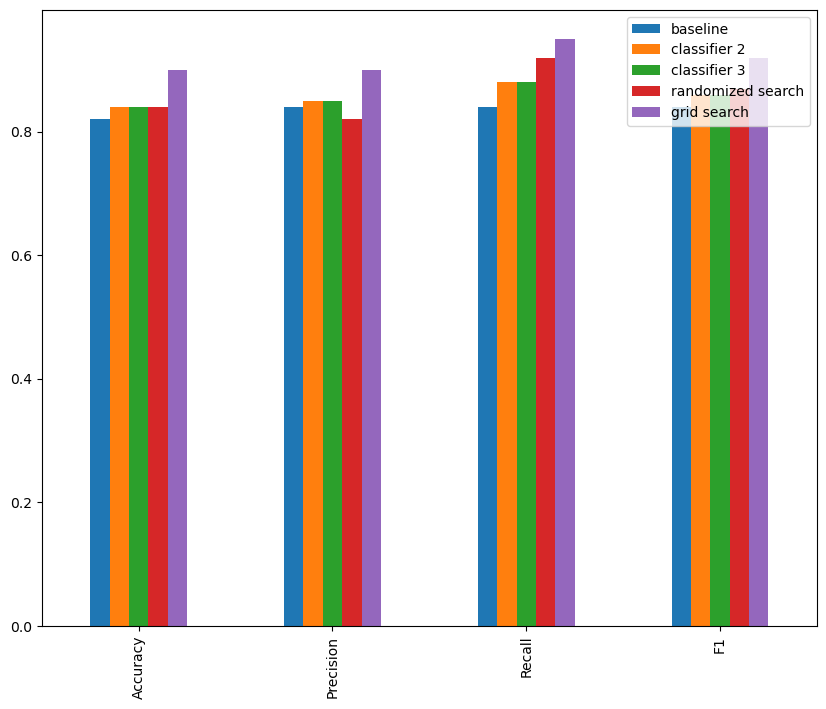

In [127]:
metrics_df.plot(figsize = (10, 8), kind="bar")

# Saving and loading trained ML models

Two ways :
* With python's `pickle` module
* With the `joblib` module

### Pickle module

In [130]:
import pickle

pickle.dump(gs_clf, open("./model/heart_disease_random_forest_model.pkl", "wb"))

In [132]:
loaded_gs_clf = pickle.load(open("./model/heart_disease_random_forest_model.pkl", "rb"))

In [133]:
loaded_gs_clf_y_preds = loaded_gs_clf.predict(X_test)

In [134]:
evaluate_preds(y_test, loaded_gs_clf_y_preds)

Accuracy score = 90.16%
Precision score = 0.90
Recall score = 0.95
F1 score = 0.92


{'Accuracy': np.float64(0.9),
 'Precision': np.float64(0.9),
 'Recall': np.float64(0.95),
 'F1': np.float64(0.92)}

### **Joblib module**

In [136]:
import joblib

joblib.dump(gs_clf, filename="./model/heart_disease_random_forest_model.joblib")

['./model/heart_disease_random_forest_model.joblib']

In [137]:
loaded_gs_clf_joblib = joblib.load(filename="./model/heart_disease_random_forest_model.joblib")

In [138]:
loaded_gs_clf_joblib_y_preds = loaded_gs_clf_joblib.predict(X_test)
evaluate_preds(y_test, loaded_gs_clf_joblib_y_preds)

Accuracy score = 90.16%
Precision score = 0.90
Recall score = 0.95
F1 score = 0.92


{'Accuracy': np.float64(0.9),
 'Precision': np.float64(0.9),
 'Recall': np.float64(0.95),
 'F1': np.float64(0.92)}